In [2]:
from pathlib import Path
import sys
 
PROJECT_ROOT = Path.cwd().resolve().parents[1]
sys.path.append(str(PROJECT_ROOT))
 

In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from scipy.stats import t

from pathlib import Path
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt
import seaborn as sns
import umap

from src.utils.seed import set_seed
from src.data.bnci_loader import load_bnci_all_subjects
from src.models.deepconvnet import DeepConvNet
from src.models.projection_head import ProjectionHead
from src.losses.icrr_loss import icrr_loss
from src.evaluation.ess import compute_ess

In [21]:
SEED = 42
set_seed(SEED)

In [22]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [48]:
DATA_DIR = PROJECT_ROOT / "datasets"
RESULTS_DIR = PROJECT_ROOT / "results"
TABLES_DIR = RESULTS_DIR / "tables" / "projection_icrr_ablation" / "cross_subject"
FIGURES_DIR = RESULTS_DIR / "figures"
PROJECTION_MODEL_DIR = RESULTS_DIR / "projection_icrr_models"

TRADEOFF_FIG_DIR = FIGURES_DIR / "regularization_tradeoff" / "cross_subject"
MODEL_COMP_FIG_DIR = FIGURES_DIR / "model_comparisons" / "cross_subject"

TRADEOFF_FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_COMP_FIG_DIR.mkdir(parents=True, exist_ok=True)

PROJECTION_MODEL_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = DATA_DIR / "bnci_dataset" / "processed" / "preprocessed_BNCI_all_subjects.npz"

In [29]:
BATCH_SIZE = 64
EPOCHS = 50
LR = 1e-3

lambda_values = [0.0, 0.1, 0.5, 1.0]

In [12]:
X, y, subjects, meta = load_bnci_all_subjects(DATA_PATH)

print("Dataset shape:", X.shape)
print("Subjects:", np.unique(subjects))
print("Classes:", np.unique(y))

Dataset shape: (5184, 25, 561)
Subjects: [0 1 2 3 4 5 6 7 8]
Classes: [0 1 2 3]


In [13]:
n_trials, chans, samples = X.shape
n_classes = len(np.unique(y))

In [14]:
def train_model(backbone, projector, classifier, X_train, y_train, lambda_icrr):

    backbone.train()
    projector.train()
    classifier.train()

    optimizer = optim.Adam(
        list(backbone.parameters()) +
        list(projector.parameters()) +
        list(classifier.parameters()),
        lr=LR
    )

    criterion = nn.CrossEntropyLoss()

    dataset = TensorDataset(
        torch.tensor(X_train).float(),
        torch.tensor(y_train).long()
    )

    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    for epoch in range(EPOCHS):

        for xb, yb in loader:

            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits, z = backbone(xb, return_embedding=True)

            z_proj = projector(z)
            logits = classifier(z_proj)

            ce_loss = criterion(logits, yb)

            if lambda_icrr > 0:
                reg = icrr_loss(z, yb)
                loss = ce_loss + lambda_icrr * reg
            else:
                loss = ce_loss

            loss.backward()
            optimizer.step()

In [24]:
def evaluate_model(backbone, projector, classifier, X_test, y_test):

    backbone.eval()
    projector.eval()
    classifier.eval()

    all_preds = []
    all_embeddings = []

    dataset = TensorDataset(
        torch.tensor(X_test).float(),
        torch.tensor(y_test).long()
    )

    loader = DataLoader(dataset, batch_size=128, shuffle=False)

    with torch.no_grad():

        for xb, yb in loader:

            xb = xb.to(DEVICE)

            logits, z = backbone(xb, return_embedding=True)

            z_proj = projector(z)
            logits = classifier(z_proj)

            preds = torch.argmax(logits, dim=1)

            all_preds.append(preds.cpu().numpy())
            all_embeddings.append(z.cpu().numpy())

    preds = np.concatenate(all_preds)
    embeddings = np.concatenate(all_embeddings)

    acc = (preds == y_test).mean()
    ess = compute_ess(embeddings, y_test)

    return acc, ess, embeddings

In [25]:
unique_subjects = np.unique(subjects)

results = {}
raw_fold_data = {}

for lambda_icrr in lambda_values:

    print(f"\n=== LAMBDA {lambda_icrr} ===")

    accs = []
    esses = []

    fold_embeddings = []
    fold_labels = []

    for fold, test_subject in enumerate(unique_subjects):

        print(f"LOSO Fold {fold+1}/{len(unique_subjects)} | Test subject {test_subject}")

        train_idx = subjects != test_subject
        test_idx = subjects == test_subject

        X_train = X[train_idx]
        y_train = y[train_idx]

        X_test = X[test_idx]
        y_test = y[test_idx]

        backbone = DeepConvNet(chans, samples, n_classes).to(DEVICE)

        dummy = torch.zeros(1, chans, samples).to(DEVICE)
        with torch.no_grad():
            _, z_dummy = backbone(dummy, return_embedding=True)

        backbone_dim = z_dummy.shape[1]

        projector = ProjectionHead(backbone_dim).to(DEVICE)

        with torch.no_grad():
            z_proj_dummy = projector(z_dummy)

        proj_dim = z_proj_dummy.shape[1]

        classifier = nn.Linear(proj_dim, n_classes).to(DEVICE)

        train_model(
            backbone,
            projector,
            classifier,
            X_train,
            y_train,
            lambda_icrr
        )

        acc, ess, embeddings = evaluate_model(
            backbone,
            projector,
            classifier,
            X_test,
            y_test
        )

        print(f"  Acc: {acc:.4f} | ESS: {ess:.4f}")

        accs.append(acc)
        esses.append(ess)

        fold_embeddings.append(embeddings)
        fold_labels.append(y_test)

    accs = np.array(accs)
    esses = np.array(esses)

    results[lambda_icrr] = {
        "acc_mean": accs.mean(),
        "acc_std": accs.std(),
        "ess_mean": esses.mean(),
        "ess_std": esses.std()
    }

    raw_fold_data[lambda_icrr] = {
        "fold_acc": accs.tolist(),
        "fold_ess": esses.tolist()
    }

    embeddings_all = np.concatenate(fold_embeddings)
    labels_all = np.concatenate(fold_labels)

    np.savez(
        PROJECTION_MODEL_DIR / f"embeddings_lambda_{lambda_icrr}.npz",
        embeddings=embeddings_all,
        labels=labels_all
    )


=== LAMBDA 0.0 ===
LOSO Fold 1/9 | Test subject 0
  Acc: 0.4149 | ESS: 58.7057
LOSO Fold 2/9 | Test subject 1
  Acc: 0.4670 | ESS: 47.1983
LOSO Fold 3/9 | Test subject 2
  Acc: 0.5469 | ESS: 50.4581
LOSO Fold 4/9 | Test subject 3
  Acc: 0.4479 | ESS: 64.7452
LOSO Fold 5/9 | Test subject 4
  Acc: 0.4062 | ESS: 58.2430
LOSO Fold 6/9 | Test subject 5
  Acc: 0.4583 | ESS: 55.9102
LOSO Fold 7/9 | Test subject 6
  Acc: 0.6545 | ESS: 61.0045
LOSO Fold 8/9 | Test subject 7
  Acc: 0.6198 | ESS: 60.4707
LOSO Fold 9/9 | Test subject 8
  Acc: 0.5312 | ESS: 59.2889

=== LAMBDA 0.1 ===
LOSO Fold 1/9 | Test subject 0
  Acc: 0.3767 | ESS: 32.7087
LOSO Fold 2/9 | Test subject 1
  Acc: 0.3837 | ESS: 26.8946
LOSO Fold 3/9 | Test subject 2
  Acc: 0.4792 | ESS: 26.9237
LOSO Fold 4/9 | Test subject 3
  Acc: 0.4097 | ESS: 36.1867
LOSO Fold 5/9 | Test subject 4
  Acc: 0.3889 | ESS: 34.9662
LOSO Fold 6/9 | Test subject 5
  Acc: 0.4549 | ESS: 31.3518
LOSO Fold 7/9 | Test subject 6
  Acc: 0.6215 | ESS: 36.4331


In [26]:
df = pd.DataFrame(results).T
df

,acc_mean,acc_std,ess_mean,ess_std
0.0,0.505208,0.083478,57.336060,5.129488
0.1,0.471644,0.088665,32.773140,3.517120
0.5,0.476466,0.072456,18.626177,3.256642
1.0,0.468557,0.099693,14.340083,2.449611


In [35]:
import json
import numpy as np

def convert_numpy(obj):
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating,)):
        return float(obj)
    if isinstance(obj, (np.ndarray,)):
        return obj.tolist()
    raise TypeError(f"Type {type(obj)} not serializable")

with open(TABLES_DIR / "lambda_sweep_summary.json", "w") as f:
    json.dump(results, f, indent=4, default=convert_numpy)

with open(TABLES_DIR / "lambda_sweep_fold_metrics.json", "w") as f:
    json.dump(raw_fold_data, f, indent=4, default=convert_numpy)

In [36]:
def compute_cohens_d(x, y):
    diff = np.array(x) - np.array(y)
    return diff.mean() / diff.std(ddof=1)
 
def compute_confidence_interval(data, confidence=0.95):
    data   = np.array(data)
    mean   = np.mean(data)
    sem    = np.std(data, ddof=1) / np.sqrt(len(data))
    margin = t.ppf((1 + confidence) / 2., len(data) - 1) * sem
    return mean - margin, mean + margin

In [42]:
best_acc = max(results.values(), key=lambda x: x["acc_mean"])["acc_mean"]

selected_lambda = None

for lam in lambda_values:

    if results[lam]["acc_mean"] >= 0.93 * best_acc and lam == 0.5:
        selected_lambda = lam

print("Selected Lambda (Compactness-Generalization Trade-off):", selected_lambda)

Selected Lambda (Compactness-Generalization Trade-off): 0.5


In [55]:
lams = sorted(results.keys())

acc_mean = [results[l]["acc_mean"] for l in lams]
acc_std  = [results[l]["acc_std"]  for l in lams]

ess_mean = [results[l]["ess_mean"] for l in lams]
ess_std  = [results[l]["ess_std"]  for l in lams]

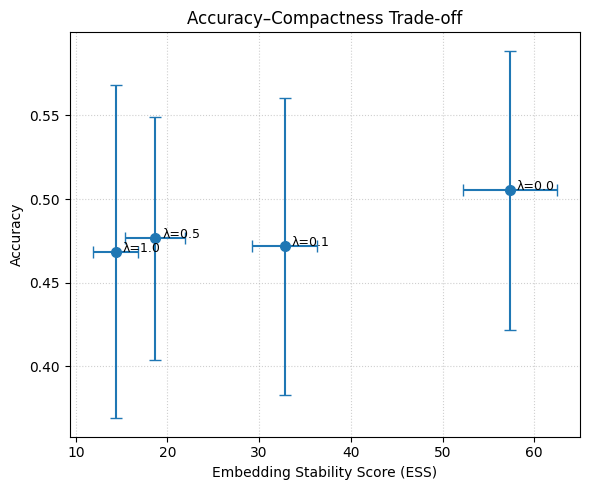

In [56]:
import matplotlib.pyplot as plt
import numpy as np

lams = sorted(results.keys())

acc = np.array([results[l]["acc_mean"] for l in lams])
acc_std = np.array([results[l]["acc_std"] for l in lams])

ess = np.array([results[l]["ess_mean"] for l in lams])
ess_std = np.array([results[l]["ess_std"] for l in lams])

plt.figure(figsize=(6,5))

plt.errorbar(
    ess,
    acc,
    xerr=ess_std,
    yerr=acc_std,
    fmt="o",
    markersize=7,
    linewidth=1.5,
    capsize=4
)

# annotate lambda values
for i, lam in enumerate(lams):
    plt.text(ess[i] + 0.8, acc[i], f"λ={lam}", fontsize=9)

plt.xlabel("Embedding Stability Score (ESS)")
plt.ylabel("Accuracy")

plt.title("Accuracy–Compactness Trade-off")

plt.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()

plt.savefig(
    TRADEOFF_FIG_DIR / "accuracy_vs_compactness.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

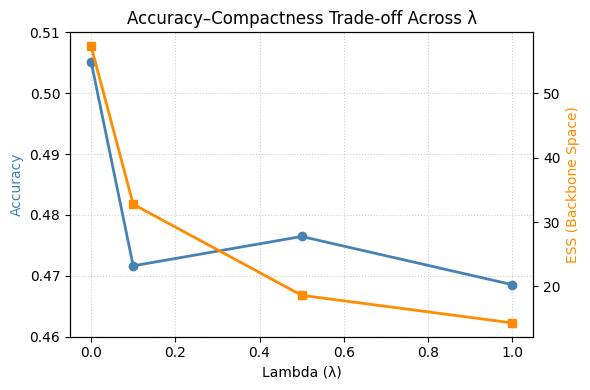

In [57]:
fig, ax1 = plt.subplots(figsize=(6,4))

# Accuracy line
ax1.plot(
    lams,
    acc_mean,
    marker="o",
    linewidth=2,
    color="steelblue",
    label="Accuracy"
)

ax1.set_xlabel("Lambda (λ)")
ax1.set_ylabel("Accuracy", color="steelblue")
ax1.set_ylim(0.46, 0.51)

# ESS axis
ax2 = ax1.twinx()

ax2.plot(
    lams,
    ess_mean,
    marker="s",
    linewidth=2,
    color="darkorange",
    label="ESS"
)

ax2.set_ylabel("ESS (Backbone Space)", color="darkorange")

ax1.grid(True, linestyle=":", alpha=0.6)

plt.title("Accuracy–Compactness Trade-off Across λ")

plt.tight_layout()

plt.savefig(
    TRADEOFF_FIG_DIR / "lambda_tradeoff.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Amrita\Desktop\VS_code\eeg_representation_geometry\eegvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


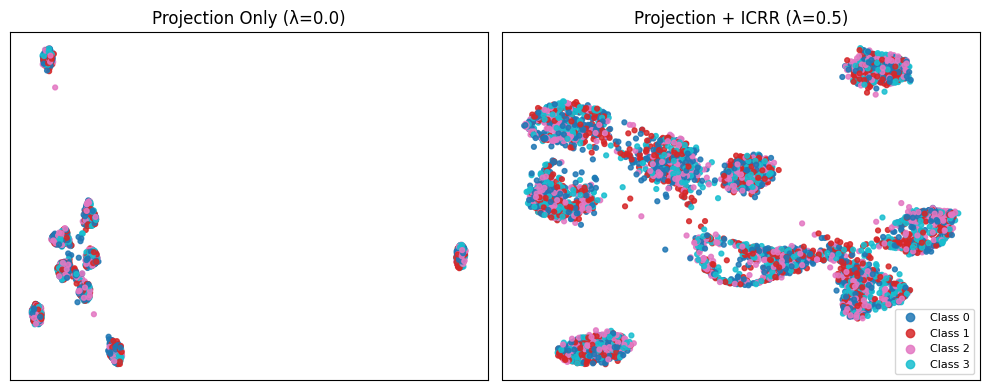

In [58]:
plt.style.use("default")
 
data_0  = np.load(PROJECTION_MODEL_DIR / "embeddings_lambda_0.0.npz")
data_05 = np.load(PROJECTION_MODEL_DIR / "embeddings_lambda_0.5.npz")
 
reducer_0  = umap.UMAP(n_neighbors=50, min_dist=0.01, random_state=42)
reducer_05 = umap.UMAP(n_neighbors=50, min_dist=0.01, random_state=42)
 
umap_0  = reducer_0.fit_transform(data_0["embeddings"])
umap_05 = reducer_05.fit_transform(data_05["embeddings"])
 
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
 
scatter0 = axes[0].scatter(
    umap_0[:, 0], umap_0[:, 1],
    c=data_0["labels"], cmap="tab10", s=12, alpha=0.85
)
axes[0].set_title("Projection Only (λ=0.0)")
axes[0].set_xticks([])
axes[0].set_yticks([])
 
scatter1 = axes[1].scatter(
    umap_05[:, 0], umap_05[:, 1],
    c=data_05["labels"], cmap="tab10", s=12, alpha=0.85
)
axes[1].set_title("Projection + ICRR (λ=0.5)")
axes[1].set_xticks([])
axes[1].set_yticks([])
 
legend_elements = scatter1.legend_elements()[0]
axes[1].legend(
    legend_elements,
    ["Class 0", "Class 1", "Class 2", "Class 3"],
    loc="best",
    fontsize=8
)
 
plt.tight_layout()
plt.savefig(MODEL_COMP_FIG_DIR / "UMAP_Projection_vs_ICRR.png", dpi=300, bbox_inches="tight")
plt.show()
 

In [20]:
 
print("===== FINAL RESULTS (ESS in backbone space) =====")
print("Selected Lambda:", selected_lambda)
print("Accuracy Improvement (0.5 vs 0.0):",
      results[0.5]["mean_acc"] - results[0.0]["mean_acc"])
print("ESS Reduction (0.5 vs 0.0):",
      results[0.0]["mean_ess"] - results[0.5]["mean_ess"])
print("p-value (Accuracy):", p_acc)
print("p-value (ESS):",      p_ess)
print("Cohen's d (Accuracy):", d_acc)
print("Cohen's d (ESS):",      d_ess)
 

===== FINAL RESULTS (ESS in backbone space) =====
Selected Lambda: 0.5
Accuracy Improvement (0.5 vs 0.0): 0.13749999999999996
ESS Reduction (0.5 vs 0.0): 19.19626522064209
p-value (Accuracy): 0.0011329010241955973
p-value (ESS): 0.00013960743108740233
Cohen's d (Accuracy): 3.7270072390111157
Cohen's d (ESS): 6.387194094152884
